In [1]:
import numpy as np
np.random.seed(42)
m=100
x= 2*np.random.rand(m,1)
y= 4 + 3*x + np.random.randn(m,1)

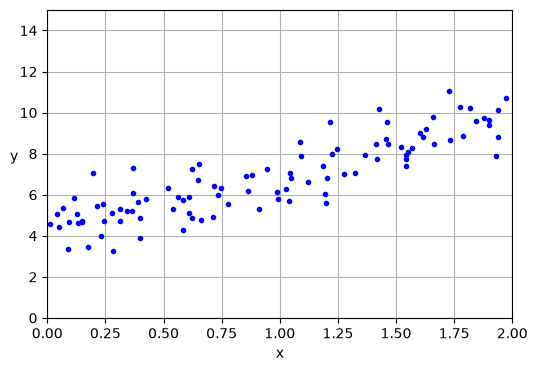

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(x,y,"b.")
plt.axis([0,2,0,15])
plt.xlabel("x")
plt.ylabel("y",rotation=0)
plt.grid()
plt.show()

In [3]:
from sklearn.preprocessing import add_dummy_feature
x_b=add_dummy_feature(x)
theta= np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y 


In [4]:
theta

array([[4.21509616],
       [2.77011339]])

In [33]:
x_new = np.array([[0],[2]])
x_new_b=add_dummy_feature(x_new)
y_predict=x_new_b @ theta


In [6]:
y_predict

array([[4.21509616],
       [9.75532293]])

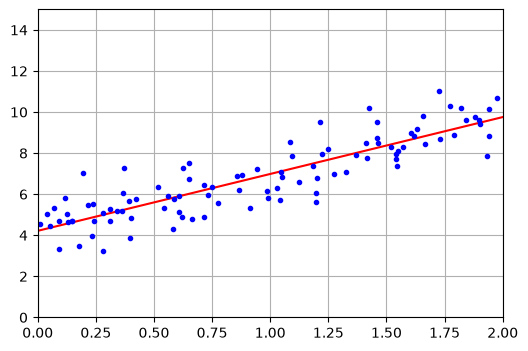

In [7]:
plt.figure(figsize=(6,4))
plt.plot(x_new,y_predict,"r-",label="Prediction")
plt.plot(x,y,'b.')
plt.axis([0,2,0,15])
plt.grid()
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression

lin=LinearRegression()
lin.fit(x,y)
lin.predict(x_new)

array([[4.21509616],
       [9.75532293]])

In [9]:
lin.intercept_

array([4.21509616])

In [10]:
lin.coef_

array([[2.77011339]])

In [11]:
#batch Gradient Descent

eta =0.01
epochs=1000
np.random.seed(42)
theta=np.random.randn(2,1)

for epoch in range(epochs):
    gradients=2/m * x_b.T @(x_b @ theta -y)
    theta = theta - eta * gradients
    

In [12]:
theta


array([[4.1935218 ],
       [2.78916237]])

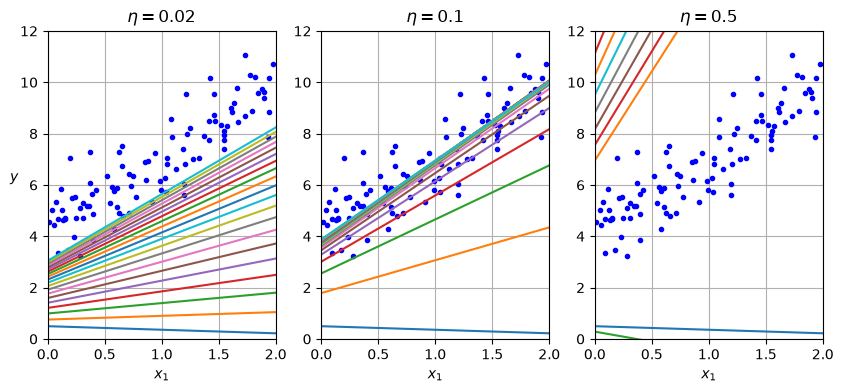

In [13]:
#ploting the graph

def plot_graph(theta,eta):
    m=len(x_b)
    epochs=1000
    n_shown=20
    theta_path=[]
    plt.plot(x,y,"b.")
    
    for epoch in range(epochs):
        if epoch < n_shown:
            y_predict=x_new_b @ theta
            plt.plot(x_new,y_predict, linestyle="solid")
        gradients=2/m *x_b.T @ (x_b @ theta -y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 12])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta=np.random.randn(2,1)

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_graph(theta,eta =0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
plot_graph(theta,eta=0.1)

plt.subplot(133)

plot_graph(theta,eta=0.5)
plt.show()

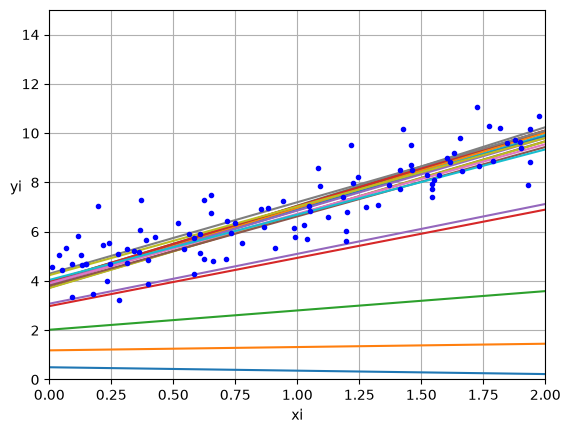

In [14]:
# stochastic Gradient Descent

epochs=50
t0,t1=5,50

def learning_rate(t):
    return t0/(t+t1)

np.random.seed(42)
theta=np.random.randn(2,1)

n_shown=20

for epoch in range(epochs):
    for iteration in range(m):
        if epoch == 0 and iteration < n_shown:

            y_predict = x_new_b @ theta
            plt.plot(x_new,y_predict)
        
        random_i= np.random.randint(m)
        xi=x_b[random_i : random_i + 1]
        yi=y[random_i : random_i + 1]

        gradients = 2*xi.T@(xi@ theta - yi)
        eta = learning_rate(epoch * m + iteration)
        theta = theta - eta * gradients
plt.plot(x,y,"b.")
plt.axis([0,2,0,15])
plt.xlabel("xi")
plt.ylabel("yi",rotation =0)
plt.grid()
plt.show()

In [15]:
theta

array([[4.21076011],
       [2.74856079]])

In [16]:
from sklearn.linear_model import SGDRegressor

SGD= SGDRegressor(max_iter=1000,penalty=None,eta0=0.01,n_iter_no_change=100,random_state=42)
SGD.fit(x,y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [17]:
SGD.intercept_,SGD.coef_

(array([4.15474433]), array([2.82564538]))

## polynomial regression

## y = x + theta @ x**2 

In [18]:
np.random.seed(42)
m=100
x=6 *np.random.rand(m,1)-3
y = x + 0.5 * x**2 + 2 + np.random.randn(m,1)

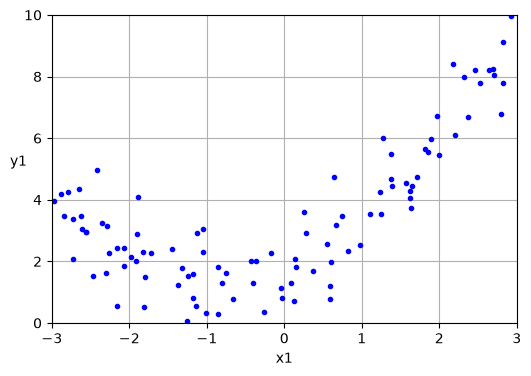

In [19]:
plt.figure(figsize=(6,4))
plt.plot(x,y,"b.")
plt.axis([-3,3,0,10])
plt.xlabel("x1")
plt.ylabel("y1",rotation =0)
plt.grid()
plt.show()

In [20]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=False)
x_p=poly.fit_transform(x)
x[0]

array([-0.75275929])

In [21]:
x_p[0]

array([-0.75275929,  0.56664654])

In [22]:
lin=LinearRegression()
lin.fit(x_p,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


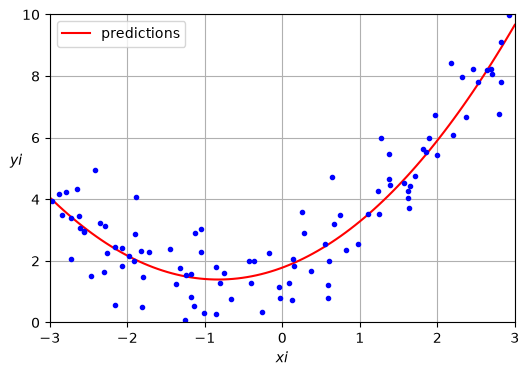

In [23]:
x_new = np.linspace(-3,3,100).reshape(100,1)
x_new_p=poly.transform(x_new)
y_new = lin.predict(x_new_p)

plt.figure(figsize=(6,4))
plt.plot(x_new,y_new,"r-",label = "predictions")
plt.plot(x,y,"b.")
plt.xlabel("$xi$")
plt.ylabel("$yi$",rotation= 0)
plt.legend(loc="upper left")
plt.axis([-3,3,0,10])
plt.grid()
plt.show()

### logistic Regression 
-> sigmod or logistic function

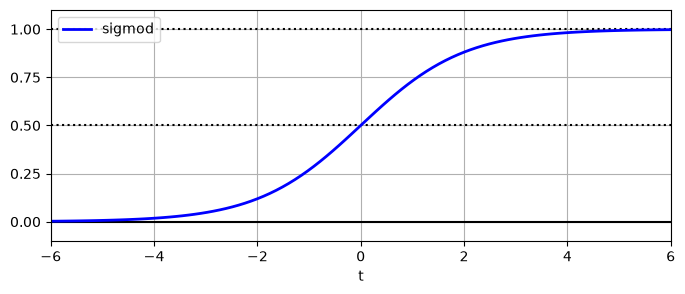

In [24]:
lim= 6
t= np.linspace(-lim,lim,100)
sig = 1/(1+np.exp(-t))
plt.figure(figsize=(8,3))

plt.plot([-lim,lim],[0,0],"k-")
plt.plot([-lim,lim],[0.50,0.50],"k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot(t,sig,"b-",linewidth =2 ,label = "sigmod")
plt.legend(loc="upper left")
plt.grid()
plt.xlabel("t")
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.axis([-lim,lim,-0.1,1.1])
plt.show()

In [25]:
from sklearn.datasets import load_iris
iris=load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [26]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [27]:
iris.target.head(3)

0    0
1    0
2    0
Name: target, dtype: int64

In [28]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x= iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target]=="virginica"

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42)

log=LogisticRegression(random_state=42)
log.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


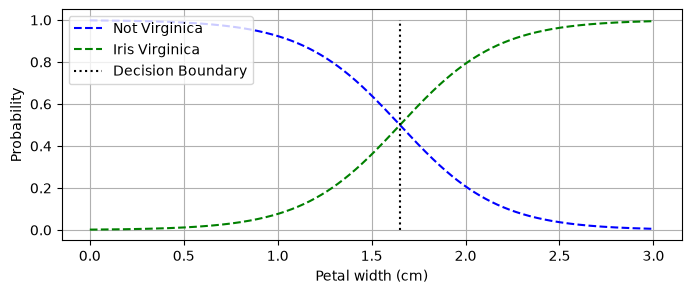

In [30]:
x_new = np.linspace(0, 3, 1000).reshape(-1, 1)

y_prob = log.predict_proba(x_new)
des = x_new[y_prob[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))

plt.plot(x_new, y_prob[:, 0], "b--", label="Not Virginica")
plt.plot(x_new, y_prob[:, 1], "g--", label="Iris Virginica")
plt.plot([des, des], [0, 1], "k:", label="Decision Boundary")

plt.grid()
plt.legend(loc="upper left")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")

plt.show()

In [31]:
des

np.float64(1.6516516516516517)

In [32]:
log.predict([[1.7],[1.5]])

array([ True, False])

logistic regression from scratch


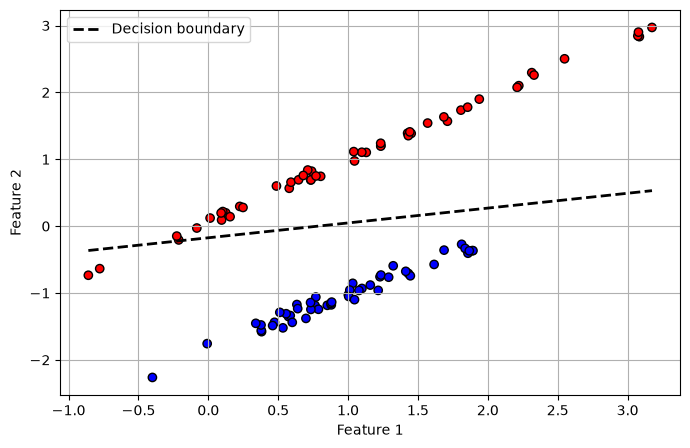

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


X, y = make_classification(n_samples=100, n_features=2, n_redundant=0,n_clusters_per_class=1,random_state=42)

y=y.reshape(-1,1)

X_b = np.c_[np.ones((100, 1)), X]

def sigmoid(z):
    return 1 / (1+np.exp(-z))

eta=0.01
epochs=1000
m=len(X_b)
theta=np.random.randn(3,1)

for epoch in range(epochs):
    h = sigmoid(X_b @ theta)
    gradients = (1/m) * X_b.T@(h-y)
    theta = theta - eta * gradients

x1_range = np .linspace((X[:,0]).min(), X[:,0].max(),100)
x2_boundary= -(theta[0] + theta[1] * x1_range )/theta[2]

plt.figure(figsize=(8,5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='bwr', edgecolors='k')
plt.plot(x1_range, x2_boundary, 'k--', linewidth=2, label='Decision boundary')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()
plt.show()


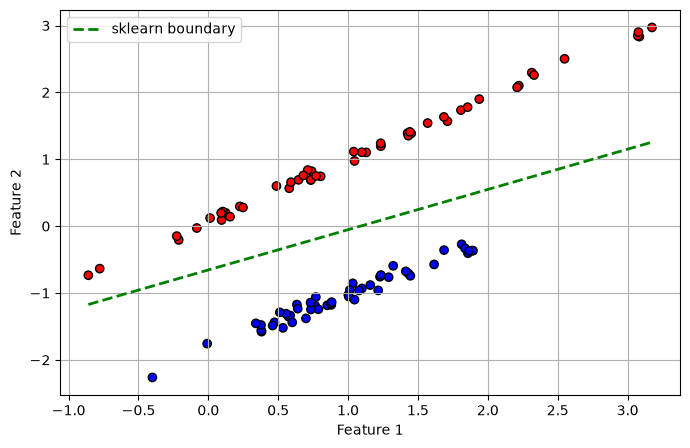

In [49]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X, y.ravel())

w = clf.coef_[0]
b = clf.intercept_[0]
x2_boundary_sk = -(b + w[0] * x1_range) / w[1]

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='bwr', edgecolors='k')
plt.plot(x1_range, x2_boundary_sk, 'g--', linewidth=2, label='sklearn boundary')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()